In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("/content/AB_NYC_2019.csv.zip")

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
df.shape

(48895, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
df.drop(columns=['id', 'host_id', 'host_name', 'last_review','name'], inplace=True)

In [7]:
df.shape

(48895, 11)

In [8]:
df.isnull().sum()

,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,10052
calculated_host_listings_count,0


In [9]:
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


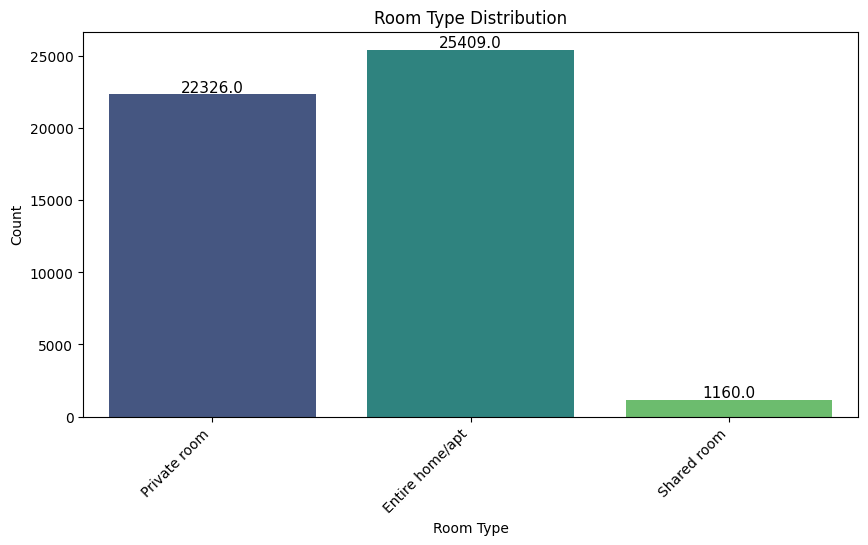

In [10]:
plt.figure(figsize=(10,5))
ax = sns.countplot(x = 'room_type',data = df, palette='viridis')
plt.title('Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Add counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

In [12]:
num_cols.isnull().sum()

,0
latitude,0
longitude,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,10052
calculated_host_listings_count,0
availability_365,0


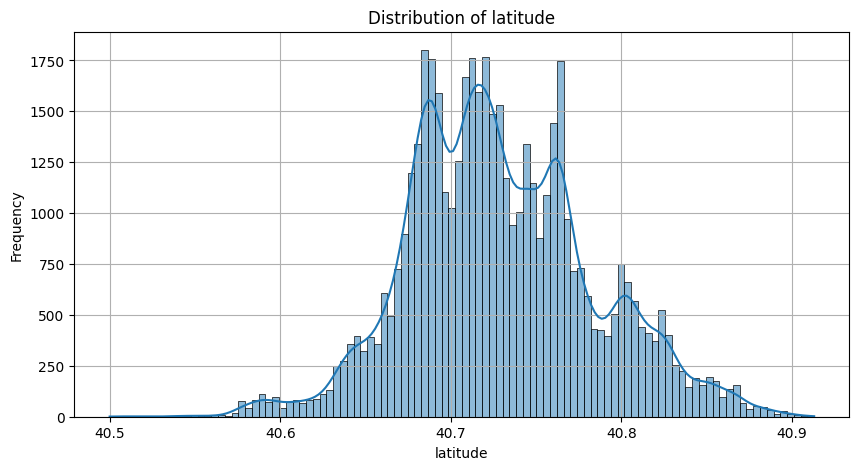

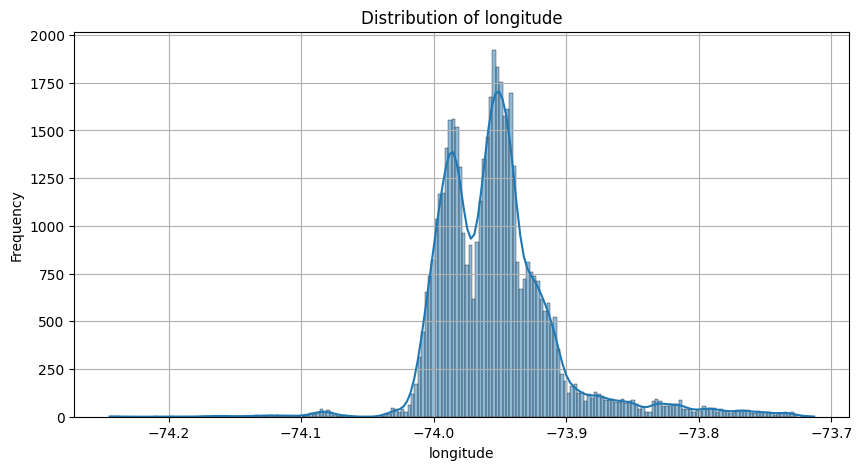

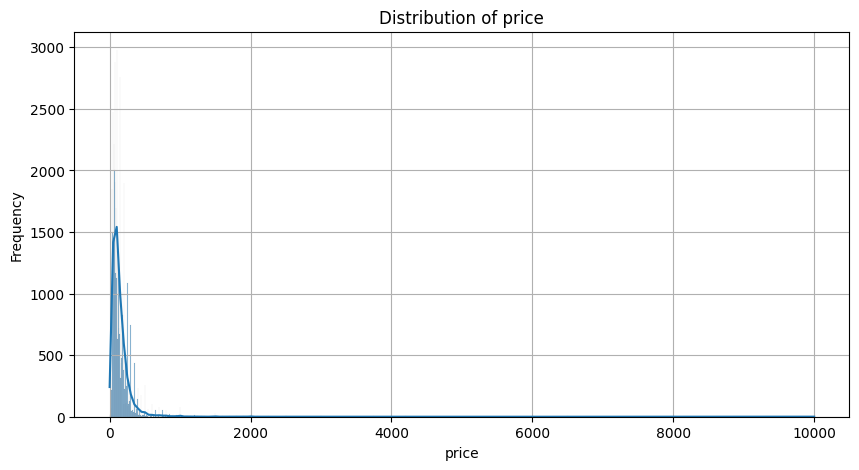

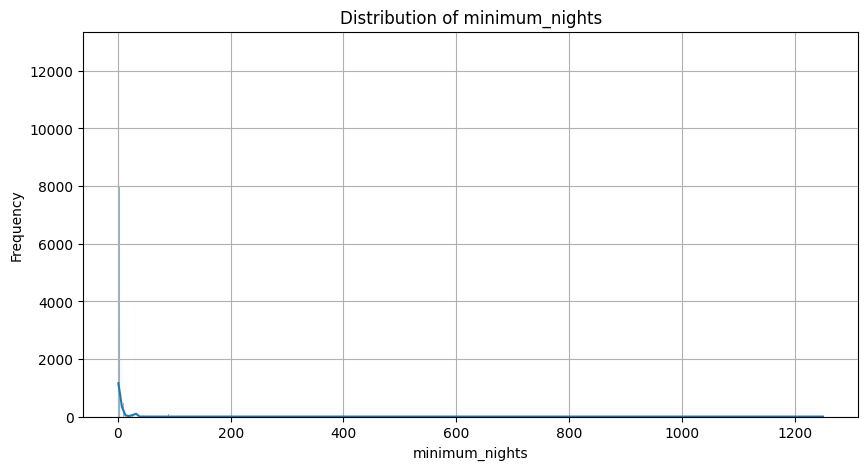

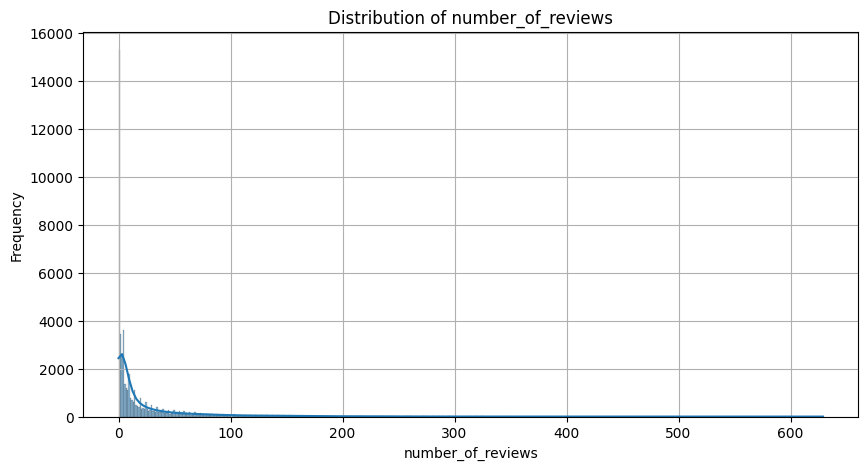

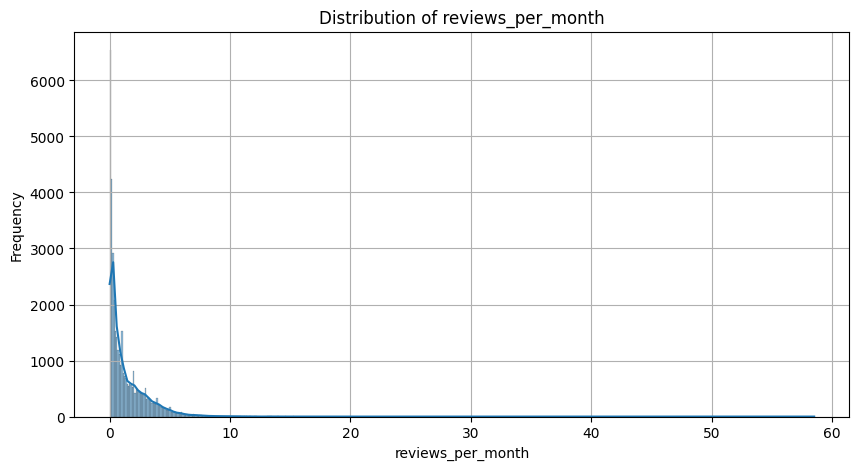

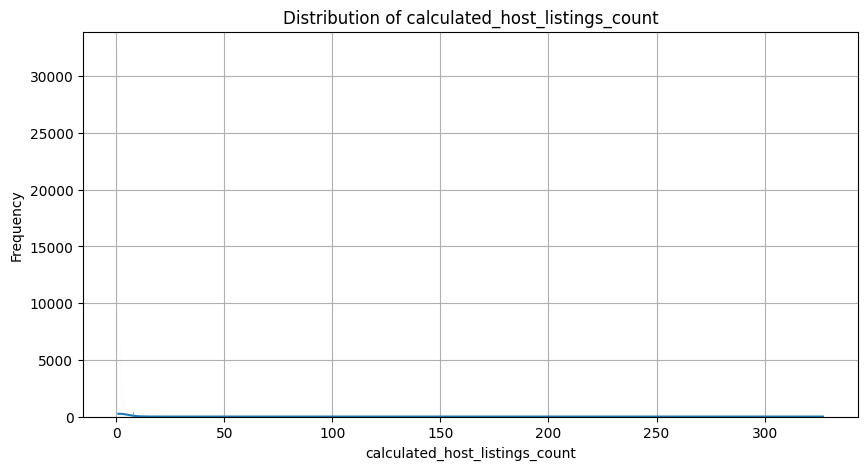

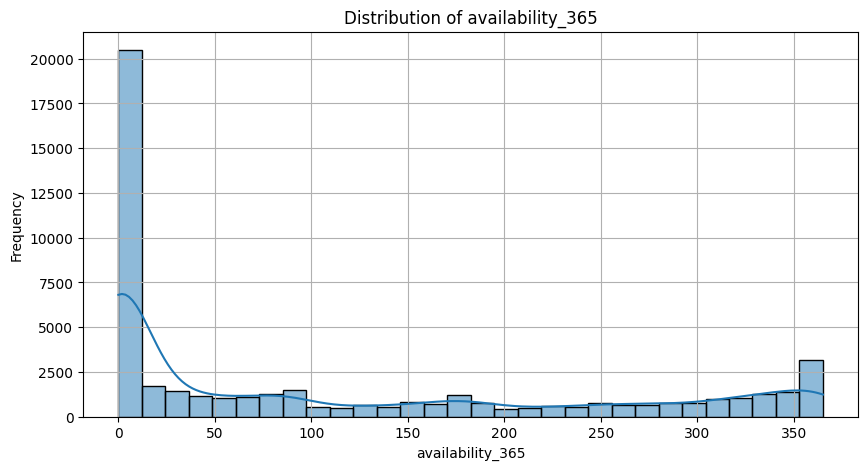

In [13]:
for i in num_cols:
  plt.figure(figsize=(10,5))
  sns.histplot(df[i],kde = True)
  plt.title(f'Distribution of {i}')
  plt.xlabel(i)
  plt.ylabel('Frequency')
  plt.grid(True)
  plt.show()

In [14]:
cat_cols = df.select_dtypes(include=['object'])

In [15]:
cat_cols.isnull().sum()

,0
neighbourhood_group,0
neighbourhood,0
room_type,0


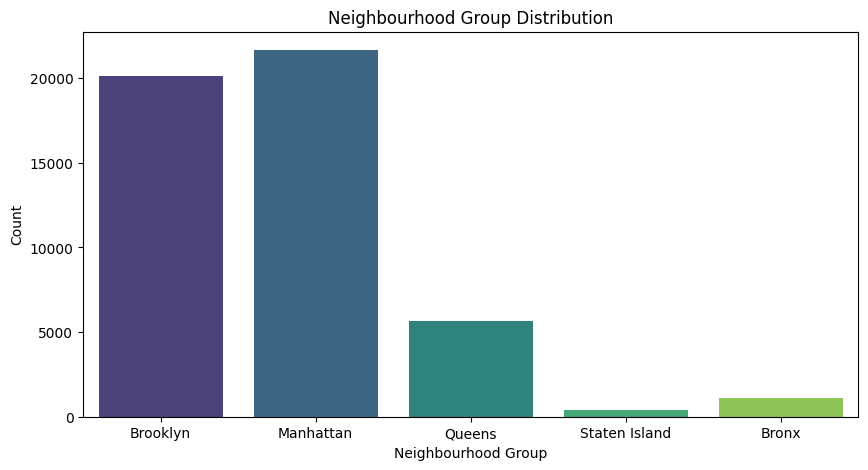

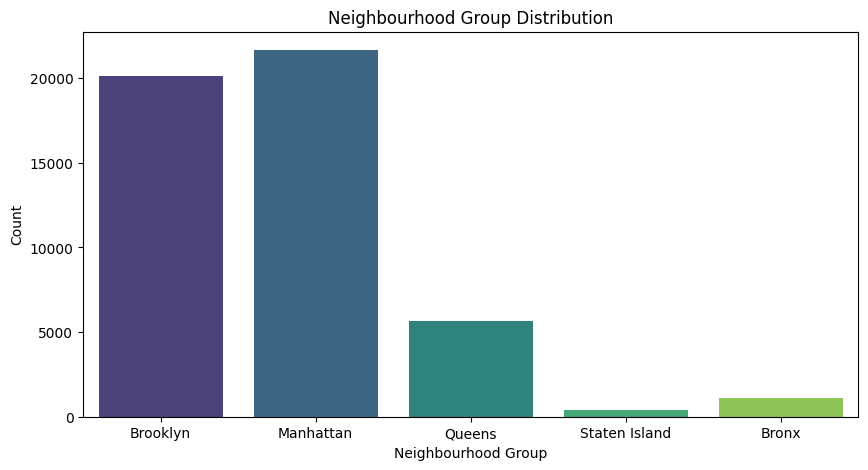

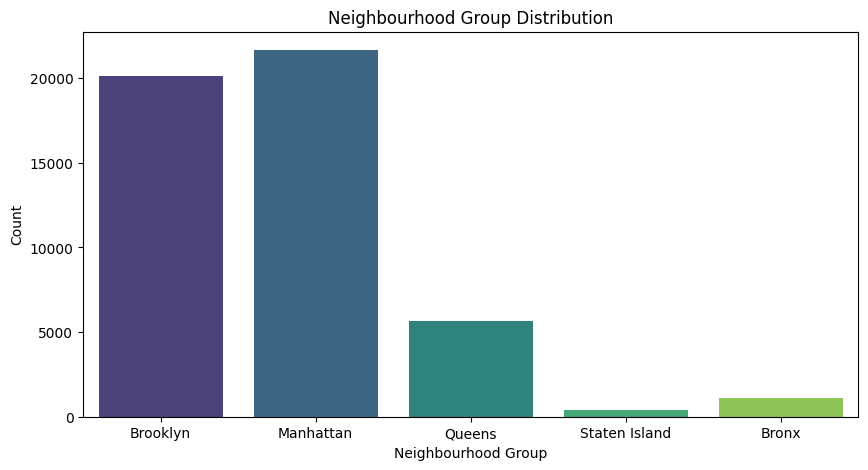

In [16]:
for j in cat_cols:
  plt.figure(figsize=(10,5))
  ax = sns.countplot(x = 'neighbourhood_group',data = df, palette='viridis')
  plt.title('Neighbourhood Group Distribution')
  plt.xlabel('Neighbourhood Group')
  plt.ylabel('Count')

Text(0, 0.5, 'Price')

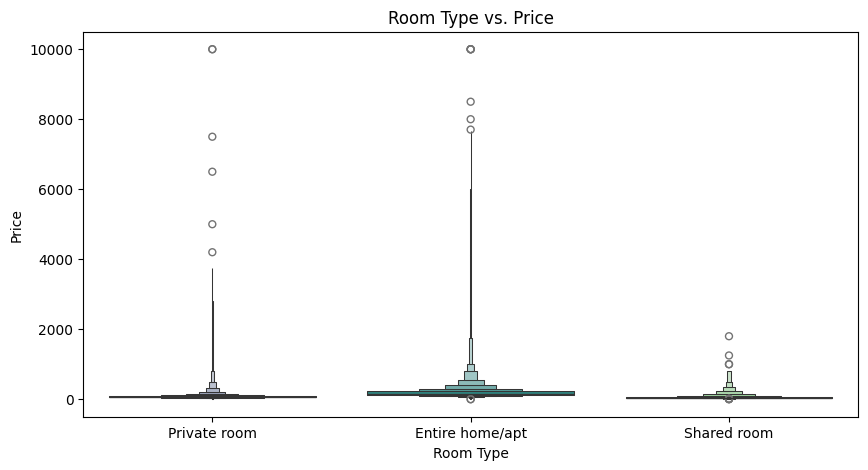

In [17]:
plt.figure(figsize=(10,5))
sns.boxenplot(x='room_type', y='price', data=df, palette='viridis')
plt.title('Room Type vs. Price')
plt.xlabel('Room Type')
plt.ylabel('Price')

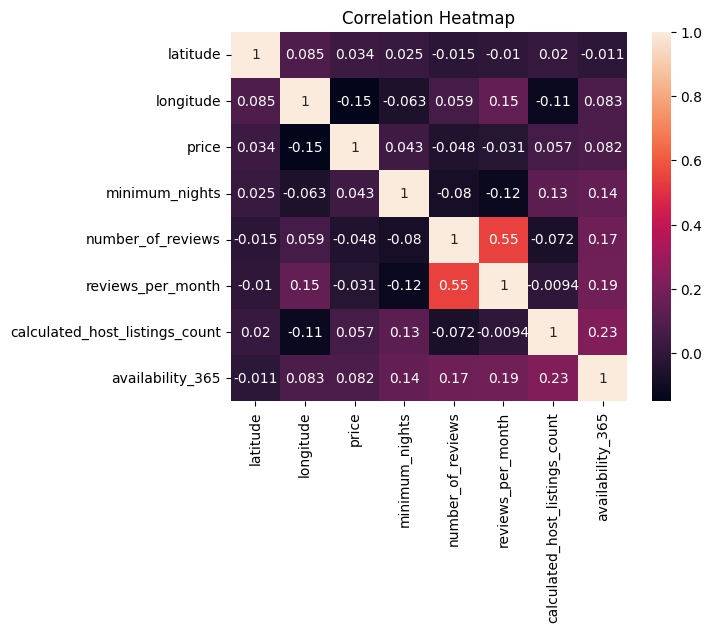

In [18]:
cor = num_cols.corr()
sns.heatmap(cor, annot=True)
plt.title('Correlation Heatmap')
plt.show()

Text(0, 0.5, 'Latitude')

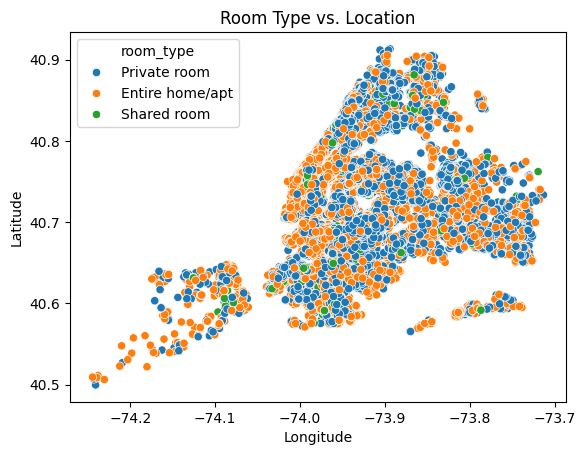

In [19]:
sns.scatterplot(x='longitude',y='latitude',data = df,hue='room_type')
plt.title('Room Type vs. Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

In [20]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

outlier are cliping

In [21]:
price_cap = df['price'].quantile(0.99)
nights_cap = df['minimum_nights'].quantile(0.99)

df['price'] = df['price'].clip(upper = price_cap)
df['minimum_nights'] = df['minimum_nights'].clip(upper = nights_cap)

In [22]:
X = df.drop(columns=['room_type'])
y = df['room_type']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [25]:
numeric_cols = ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']
categorical_cols = ['neighbourhood_group', 'neighbourhood']

numeric_Pipeline = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

categorical_Pipeline = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    ("numeric", numeric_Pipeline,numeric_cols),
    ("categorical", categorical_Pipeline,categorical_cols)
])

In [26]:
preprocess

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['latitude', 'longitude', 'price',
                                  'minimum_nights', 'number_of_reviews',
                                  'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [28]:
models = {
    "logistic": LogisticRegression(class_weight="balanced",random_state=42),
    "decision_tree": DecisionTreeClassifier(class_weight="balanced",random_state=42),
    "random_forest": RandomForestClassifier(class_weight="balanced",random_state=42),
    "gradient_boosting": GradientBoostingClassifier(random_state=42)
}

for name,model in models.items():
  pipe = Pipeline(steps=[("preprocessor",preprocess),("model",model)])
  accuracy = cross_val_score(pipe,X_train,y_train,cv=5,scoring="accuracy")
  macro_f1 = cross_val_score(pipe,X_train,y_train,cv=5,scoring="f1_macro")
  print(f"{name}->Accuracy:{accuracy.mean():.3f} , F1 Score:{macro_f1.mean():.3f}")

logistic->Accuracy:0.662 , F1 Score:0.525
decision_tree->Accuracy:0.788 , F1 Score:0.658
random_forest->Accuracy:0.854 , F1 Score:0.720
gradient_boosting->Accuracy:0.851 , F1 Score:0.705


In [32]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ("preprocessor",preprocess),
    ("classifier",RandomForestClassifier(class_weight="balanced",random_state=42))
])

param_gris = {
    "classifier__n_estimators":[100,200,150,300],
    "classifier__max_depth":[None,5,8,10,15,20],
    "classifier__min_samples_split":[2,5,10],
    "classifier__min_samples_leaf":[1,2,4]
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_gris,
    cv=3,
    n_iter=10,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1
)

search.fit(X_train,y_train)

print("Best_Perameters",search.best_params_)
print("Best CV mecro-f1",search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best_Perameters {'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None}
Best CV mecro-f1 0.8533591821324115


In [33]:
from sklearn.metrics import accuracy_score,classification_report,f1_score
best_pipeline = search.best_estimator_
y_pred  = best_pipeline.predict(X_test)

print(f"Accuracy:{accuracy_score(y_test,y_pred):.3f}")
print(f"F1 Score:{f1_score(y_test,y_pred,average='macro'):.3f}")
print(classification_report(y_test,y_pred))

Accuracy:0.856
F1 Score:0.726
                 precision    recall  f1-score   support

Entire home/apt       0.87      0.88      0.88      5082
   Private room       0.84      0.85      0.85      4465
    Shared room       0.93      0.30      0.46       232

       accuracy                           0.86      9779
      macro avg       0.88      0.68      0.73      9779
   weighted avg       0.86      0.86      0.85      9779



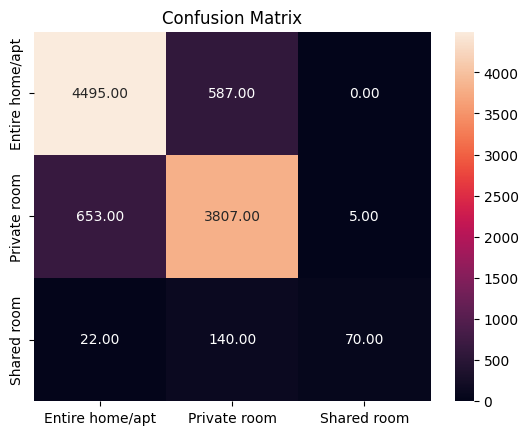

In [40]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='.2f',xticklabels=best_pipeline.classes_,yticklabels=best_pipeline.classes_)
plt.title("Confusion Matrix")
plt.show()

In [42]:
import joblib

joblib.dump(best_pipeline,"Model_Pipeline.pkl")

['Model_Pipeline.pkl']